Multiple LLM calls sequentially.

Here,

START --> input topic --> LLM generates an outline --> LLM generates a blog based on outline --> END

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
model = ChatOpenAI(model="gpt-4.1-nano", max_tokens=500)

In [15]:
class LLMState(TypedDict):
    topic: str
    outline: str
    blog: str

In [16]:
def gen_outline(state: LLMState) -> LLMState:
    topic = state['topic']
    prompt = f'Generate a detailed outline for a blog post about the following topic: {topic}'
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

def gen_blog(state: LLMState) -> LLMState:
    topic = state['topic']
    outline = state['outline']
    prompt = f'Write a blog post about the following topic: {topic} using the following outline: {outline}'
    blog = model.invoke(prompt).content
    state['blog'] = blog
    return state

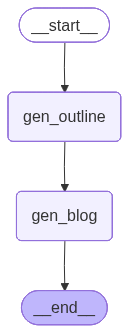

In [17]:
graph = StateGraph(LLMState)
graph.add_node("gen_outline", gen_outline)
graph.add_node("gen_blog", gen_blog)
graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_blog')
graph.add_edge('gen_blog', END)
workflow = graph.compile()
workflow

In [18]:
initial_state = {"topic": "The Future of AI in Healthcare"}
final_state = workflow.invoke(initial_state)
final_state

{'topic': 'The Future of AI in Healthcare',
 'outline': '**Blog Post Title:**  \nThe Future of AI in Healthcare: Revolutionizing Medicine and Patient Care\n\n---\n\n### Introduction  \n- Brief overview of AI’s current role in healthcare  \n- Importance of technological advancement for improving patient outcomes  \n- Purpose of the article: exploring emerging trends, challenges, and future prospects\n\n---\n\n### 1. The Evolution of AI in Healthcare  \n- Early applications: diagnostic tools, administrative automation  \n- Key milestones and breakthroughs to date  \n- Current capabilities: machine learning, natural language processing, imaging analysis\n\n---\n\n### 2. Emerging Trends Shaping the Future of AI in Healthcare  \n#### a. Personalized Medicine  \n- Genomic data analysis for tailored treatments  \n- AI-driven drug discovery and development  \n#### b. Predictive Analytics and Preventative Care  \n- Early detection of diseases through data patterns  \n- Risk stratification model

In [19]:
print(final_state['outline'])

**Blog Post Title:**  
The Future of AI in Healthcare: Revolutionizing Medicine and Patient Care

---

### Introduction  
- Brief overview of AI’s current role in healthcare  
- Importance of technological advancement for improving patient outcomes  
- Purpose of the article: exploring emerging trends, challenges, and future prospects

---

### 1. The Evolution of AI in Healthcare  
- Early applications: diagnostic tools, administrative automation  
- Key milestones and breakthroughs to date  
- Current capabilities: machine learning, natural language processing, imaging analysis

---

### 2. Emerging Trends Shaping the Future of AI in Healthcare  
#### a. Personalized Medicine  
- Genomic data analysis for tailored treatments  
- AI-driven drug discovery and development  
#### b. Predictive Analytics and Preventative Care  
- Early detection of diseases through data patterns  
- Risk stratification models for chronic illnesses  
#### c. Robotics and Automation  
- Surgical robots enha

In [20]:
print(final_state['blog'])

**The Future of AI in Healthcare: Revolutionizing Medicine and Patient Care**

---

### Introduction

Artificial Intelligence (AI) has rapidly become an integral part of the healthcare landscape. From assisting in diagnostics to streamlining administrative workflows, AI’s current role is transforming how healthcare professionals diagnose, treat, and manage patient care. As technology advances at an unprecedented pace, leveraging AI holds the promise of significantly improving patient outcomes and making healthcare more accessible, efficient, and personalized. 

In this article, we will explore the emerging trends driving AI's future in healthcare, the challenges that need addressing, and the exciting possibilities that lie ahead.

---

### 1. The Evolution of AI in Healthcare

**Early applications:**  
AI's journey in healthcare began with simple diagnostic tools that helped identify diseases like leukemia through pattern recognition. Administrative automation, including scheduling and

Note that when this was done by LangChain, we would only get the final output which is the blog, there was no way to access the outline. But here, since the state contains all the information, we can access them at any time.